## Linear-Gaussian SSM

In [1]:
from jax import numpy as jnp
from jax import random as jr
from jax import vmap
from matplotlib import pyplot as plt

from dynamax.utils.plotting import plot_uncertainty_ellipses
from dynamax.linear_gaussian_ssm import LinearGaussianSSM
from dynamax.linear_gaussian_ssm import lgssm_smoother, lgssm_filter

In [2]:
state_dim = 4
emission_dim = 2
delta = 1.0

# Create object
lgssm = LinearGaussianSSM(state_dim, emission_dim)

# Manually chosen parameters
initial_mean = jnp.array([8.0, 10.0, 1.0, 0.0])
initial_covariance = jnp.eye(state_dim) * 0.1
dynamics_weights  = jnp.array([[1, 0, delta, 0],
                               [0, 1, 0, delta],
                               [0, 0, 1, 0],
                               [0, 0, 0, 1]])
dynamics_covariance = jnp.eye(state_dim) * 0.001
emission_weights = jnp.array([[1.0, 0, 0, 0],
                              [0, 1.0, 0, 0]])
emission_covariance = jnp.eye(emission_dim)

# Initialize model
params, _ = lgssm.initialize(jr.PRNGKey(0),
                             initial_mean=initial_mean,
                             initial_covariance=initial_covariance,
                             dynamics_weights=dynamics_weights,
                             dynamics_covariance=dynamics_covariance,
                             emission_weights=emission_weights,
                             emission_covariance=emission_covariance)

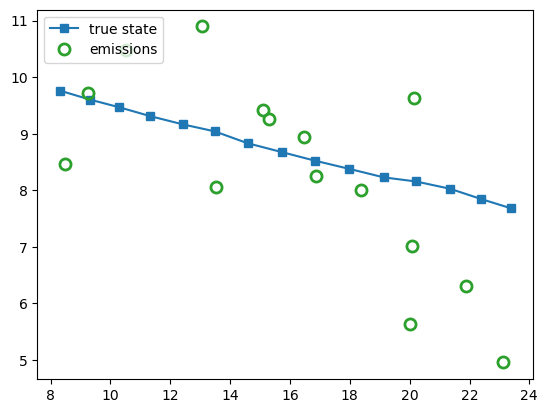

In [3]:
num_timesteps = 15
key = jr.PRNGKey(310)
x, y = lgssm.sample(params, key, num_timesteps)

# Plot Data
observation_marker_kwargs = {"marker": "o", "markerfacecolor": "none", "markeredgewidth": 2, "markersize": 8}
fig1, ax1 = plt.subplots()
ax1.plot(*x[:, :2].T, marker="s", color="C0", label="true state")
ax1.plot(*y.T, ls="", **observation_marker_kwargs, color="tab:green", label="emissions")
ax1.legend(loc="upper left")

In [4]:
lgssm_posterior = lgssm.filter(params, y)
print(lgssm_posterior.filtered_means.shape)
print(lgssm_posterior.filtered_covariances.shape)
print(lgssm_posterior.marginal_loglik)

(15, 4)
(15, 4, 4)
-51.273426


In [5]:
def plot_lgssm_posterior(post_means, post_covs, ax=None, ellipse_kwargs={}, legend_kwargs={}, **kwargs):
    """Plot posterior means and covariances for the first two dimensions of
     the latent state of a LGSSM.

    Args:
        post_means: array(T, D).
        post_covs: array(T, D, D).
        ax: matplotlib axis.
        ellipse_kwargs: keyword arguments passed to matplotlib.patches.Ellipse().
        **kwargs: passed to ax.plot().
    """
    if ax is None:
        fig, ax = plt.subplots()

    # This is to stop some weird behaviour where running the function multiple
    # #  times with an empty argument wouldn't reset the dictionary.
    # if ellipse_kwargs is None:
    #     ellipse_kwargs = dict()

    # if 'edgecolor' not in ellipse_kwargs:
    #     if 'color' in kwargs:
    #         ellipse_kwargs['edgecolor'] = kwargs['color']

    # Select the first two dimensions of the latent space.
    post_means = post_means[:, :2]
    post_covs = post_covs[:, :2, :2]

    # Plot the mean trajectory
    ax.plot(post_means[:, 0], post_means[:, 1], **kwargs)
    # Plot covariance at each time point.
    plot_uncertainty_ellipses(post_means, post_covs, ax, **ellipse_kwargs)

    ax.axis("equal")

    if "label" in kwargs:
        ax.legend(**legend_kwargs)

    return ax

<Axes: >

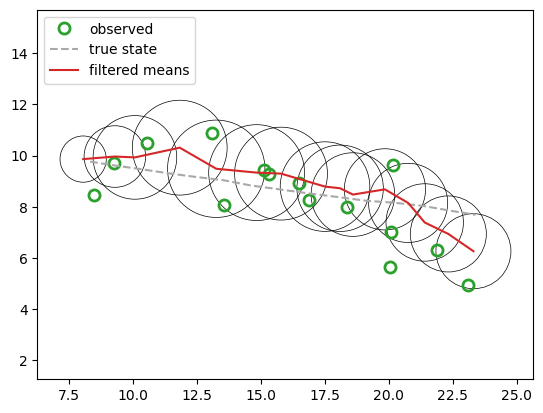

In [6]:
fig2, ax2 = plt.subplots()
ax2.plot(*y.T, ls="", **observation_marker_kwargs, color="tab:green", label="observed")
ax2.plot(*x[:, :2].T, ls="--", color="darkgrey", label="true state")
plot_lgssm_posterior(
    lgssm_posterior.filtered_means,
    lgssm_posterior.filtered_covariances,
    ax2,
    color="tab:red",
    label="filtered means",
    ellipse_kwargs={"edgecolor": "k", "linewidth": 0.5},
    legend_kwargs={"loc":"upper left"}
)

In [7]:
lgssm_posterior = lgssm.smoother(params, y)

<Axes: >

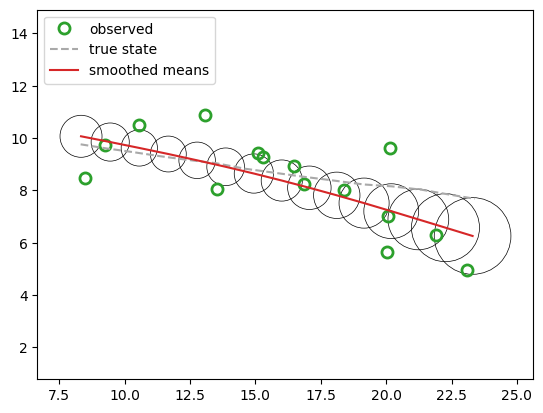

In [ ]:
fig3, ax3 = plt.subplots()
ax3.plot(*y.T, ls="", **observation_marker_kwargs, color="tab:green", label="observed")
ax3.plot(*x[:, :2].T, ls="--", color="darkgrey", label="true state")
plot_lgssm_posterior(
    lgssm_posterior.smoothed_means,
    lgssm_posterior.smoothed_covariances,
    ax3,
    color="tab:red",
    label="smoothed means",
    ellipse_kwargs={"edgecolor": "k", "linewidth": 0.5},
    legend_kwargs={"loc":"upper left"}
)

## Poisson LDS

In [ ]:
import dynamax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from jax import vmap
from jax.nn import softplus
from tensorflow_probability.substrates.jax.distributions import Poisson

from dynamax.generalized_gaussian_ssm import ParamsGGSSM, GeneralizedGaussianSSM, EKFIntegrals
from dynamax.generalized_gaussian_ssm import conditional_moments_gaussian_smoother as cmgs
from dynamax.utils.utils import random_rotation

In [ ]:
# Parameters for our Poisson demo
state_dim = 2
emission_dim = 10
num_timesteps = 200
num_trials = 3

# Sample random parameters
dynamics_matrix = random_rotation(jr.PRNGKey(0), state_dim, theta=jnp.pi/20)
emission_matrix = jr.normal(jr.PRNGKey(0), shape=(emission_dim, state_dim))
emission_bias = 3.0

# Create a generalized Gaussian SSM with Poisson emissions
params = ParamsGGSSM(
    initial_mean = jnp.zeros(state_dim),
    initial_covariance = jnp.eye(state_dim),
    dynamics_function = lambda z: dynamics_matrix @ z,
    dynamics_covariance = 0.001 * jnp.eye(state_dim),
    emission_mean_function = lambda z: softplus(emission_matrix @ z + emission_bias),
    emission_cov_function = lambda z: jnp.diag(softplus(emission_matrix @ z + emission_bias)),
    emission_dist = lambda mu, Sigma: Poisson(rate=softplus(mu))
)
model = GeneralizedGaussianSSM(state_dim, emission_dim)

# Sample several "trials" worth of data from the model
all_states, all_emissions = \
    vmap(lambda key: model.sample(params, key, num_timesteps=num_timesteps))(
        jr.split(jr.PRNGKey(0), num_trials))

In [ ]:
def plot_emissions_poisson(states, data):
    """
    Plot the emissions of a Poisson :DS
    """
    latent_dim = states.shape[-1]
    emissions_dim = data.shape[-1]
    num_timesteps = data.shape[0]

    fig, axs = plt.subplots(2, 2, 
                            height_ratios=(1, emissions_dim / latent_dim), 
                            width_ratios=(20,1), figsize=(8, 6))
    
    # Plot the continuous latent states
    lim = 1.5 * abs(states).max()
    for d in range(latent_dim):
        axs[0,0].axhline(-lim * d, color='k', ls=':', lw=1)
        axs[0,0].plot(states[:, d] - lim * d, "-")
    axs[0,0].set_yticks(-jnp.arange(latent_dim) * lim)
    axs[0,0].set_yticklabels(["$x_{}$".format(d + 1) for d in range(latent_dim)])
    axs[0,0].set_xticks([])
    axs[0,0].set_xlim(0, num_timesteps)
    axs[0,0].set_title(r"Latent States $x$")

    axs[0,1].set_visible(False)

    lim = abs(data).max()
    im = axs[1,0].imshow(data.T, aspect="auto", interpolation="none", cmap="Greys")
    axs[1,0].set_xlabel("time")
    axs[1,0].set_xlim(0, num_timesteps - 1)
    axs[1,0].set_yticks(jnp.arange(emissions_dim))
    axs[1,0].set_yticklabels([rf"$y_{{ {i+1}}}$" for i in jnp.arange(emissions_dim)])
    axs[1,0].set_ylabel("Emission dimension")
    axs[1,0].set_title(r"Emissions $y$")
    plt.colorbar(im, cax=axs[1,1], label="count")

    plt.tight_layout()
    
plot_emissions_poisson(all_states[0], all_emissions[0])

In [ ]:
posts = vmap(lambda emissions: cmgs(params, EKFIntegrals(), emissions))(all_emissions)

In [ ]:
i = 0
fig, axs = plt.subplots(2, 1, sharex=True)
lim = 1.5 * abs(all_states[i]).max()
for d in range(2):
    axs[d].plot(all_states[i, :, d], "-k", label="true")
    axs[d].plot(posts.filtered_means[i, :, d], "-r", label="inferred")
    axs[d].fill_between(
        jnp.arange(num_timesteps),
        posts.filtered_means[i, :, d] - 2 * jnp.sqrt(posts.filtered_covariances[i, :, d, d]),
        posts.filtered_means[i, :, d] + 2 * jnp.sqrt(posts.filtered_covariances[i, :, d, d]),
        color="r",
        alpha=0.25,
    )
    axs[d].set_ylabel(rf"$x_{d+1}$")

axs[-1].set_xlabel(r"time $t$")    
axs[-1].legend(loc="lower right")
axs[-1].set_xlim(0, num_timesteps)
axs[0].set_title("true and inferred states using CMGS")